# Chapter 3: Rule-Based Classifiers
This notebook contains Python demonstrations for the lecture on **Rule-Based Classifiers** (Chapter 3).

## Section 1: Sequential Covering Algorithm (Illustration)

In [1]:
# Minh họa đơn giản cách tạo ra một luật bao phủ (sequential covering)
# Chúng ta sẽ sử dụng bộ dữ liệu Iris

from sklearn.datasets import load_iris
import pandas as pd

# Load dữ liệu Iris
iris = load_iris(as_frame=True)
df = iris.frame

# Giả sử ta muốn tạo luật: Nếu chiều dài đài hoa > 5.0 thì class là gì?
rule = (df['sepal length (cm)'] > 5.0)
covered = df[rule]

print("Rule: If sepal length > 5.0 THEN class =",
      iris.target_names[covered['target'].mode()[0]])

Rule: If sepal length > 5.0 THEN class = virginica


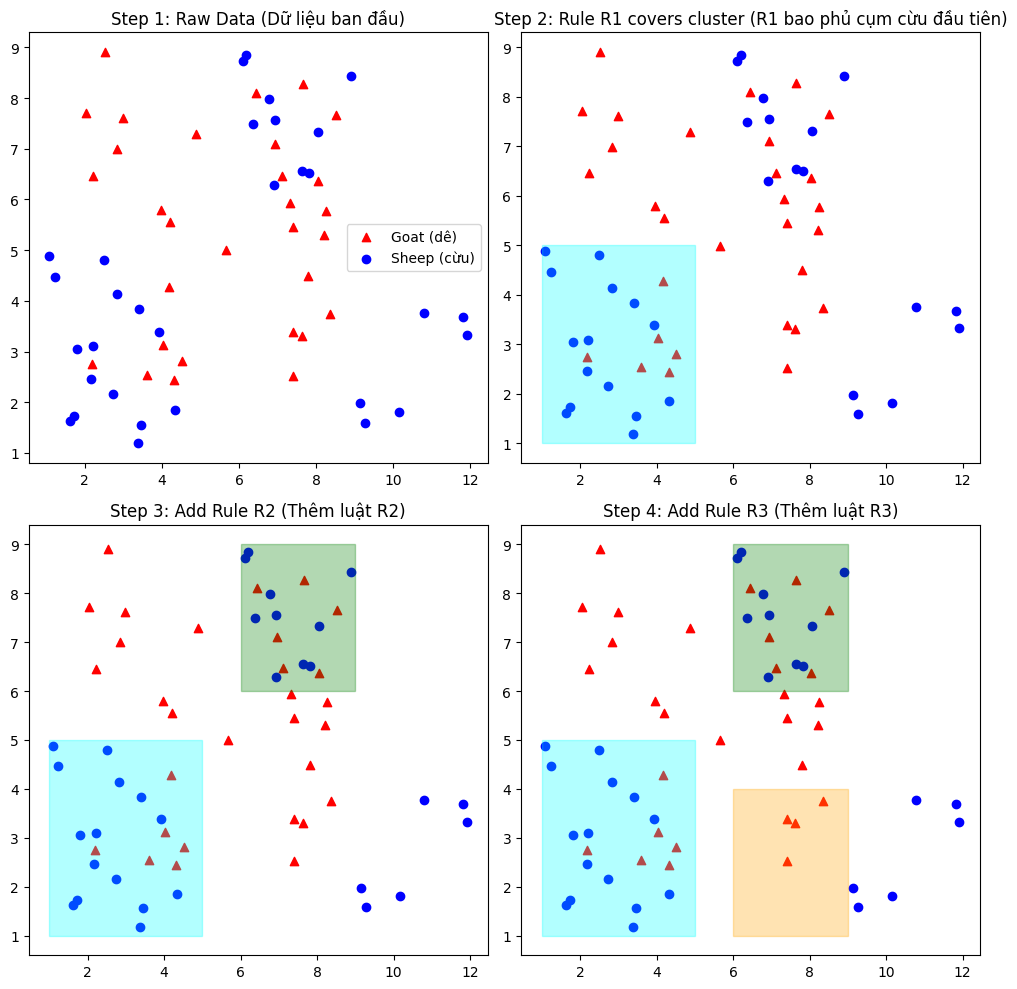

In [2]:
# Minh họa thuật toán Sequential Covering (Hình 3.1):
# 1. Goat (▲) tô màu đỏ
# 2. Sheep (●) tô màu xanh dương

import matplotlib.pyplot as plt
import numpy as np

# ===============================
# TẠO DỮ LIỆU GIẢ LẬP
# ===============================

# Đặt seed để kết quả sinh dữ liệu ngẫu nhiên có thể lặp lại
np.random.seed(42)

# Sinh 3 cụm dữ liệu cho lớp Sheep (cừu) - màu xanh dương
sheep_x = np.random.uniform(1, 5, (15, 2))    # Cụm Sheep 1
sheep_y = np.random.uniform(6, 9, (10, 2))    # Cụm Sheep 2
sheep_z = np.random.uniform(6, 9, (6, 2)) + np.array([[3, -5]])  # Cụm Sheep 3

# Sinh dữ liệu cho lớp Goat (dê) - màu đỏ
goat = np.random.uniform(2, 9, (30, 2))

# Ghép tất cả dữ liệu Sheep lại với nhau
sheep = np.vstack([sheep_x, sheep_y, sheep_z])

# ===============================
# VẼ 4 BƯỚC SEQUENTIAL COVERING
# ===============================
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# --- Step 1: Dữ liệu ban đầu ---
axes[0,0].scatter(goat[:,0], goat[:,1], marker='^', color='red', label="Goat (dê)")
axes[0,0].scatter(sheep[:,0], sheep[:,1], marker='o', color='blue', label="Sheep (cừu)")
axes[0,0].set_title("Step 1: Raw Data (Dữ liệu ban đầu)")
axes[0,0].legend()

# --- Step 2: Tạo luật đầu tiên R1 ---
axes[0,1].scatter(goat[:,0], goat[:,1], marker='^', color='red')
axes[0,1].scatter(sheep[:,0], sheep[:,1], marker='o', color='blue')
# Vẽ hình chữ nhật đại diện cho Rule R1
axes[0,1].add_patch(plt.Rectangle((1,1), 4,4, fill=True, alpha=0.3, color="cyan"))
axes[0,1].set_title("Step 2: Rule R1 covers cluster (R1 bao phủ cụm cừu đầu tiên)")

# --- Step 3: Thêm luật thứ hai R2 ---
axes[1,0].scatter(goat[:,0], goat[:,1], marker='^', color='red')
axes[1,0].scatter(sheep[:,0], sheep[:,1], marker='o', color='blue')
axes[1,0].add_patch(plt.Rectangle((1,1), 4,4, fill=True, alpha=0.3, color="cyan"))   # R1
axes[1,0].add_patch(plt.Rectangle((6,6), 3,3, fill=True, alpha=0.3, color="green"))  # R2
axes[1,0].set_title("Step 3: Add Rule R2 (Thêm luật R2)")

# --- Step 4: Thêm luật thứ ba R3 ---
axes[1,1].scatter(goat[:,0], goat[:,1], marker='^', color='red')
axes[1,1].scatter(sheep[:,0], sheep[:,1], marker='o', color='blue')
axes[1,1].add_patch(plt.Rectangle((1,1), 4,4, fill=True, alpha=0.3, color="cyan"))   # R1
axes[1,1].add_patch(plt.Rectangle((6,6), 3,3, fill=True, alpha=0.3, color="green"))  # R2
axes[1,1].add_patch(plt.Rectangle((6,1), 3,3, fill=True, alpha=0.3, color="orange")) # R3
axes[1,1].set_title("Step 4: Add Rule R3 (Thêm luật R3)")

# Canh chỉnh layout cho đẹp
plt.tight_layout()
plt.show()


C:\Users\PHT\AppData\Local\Temp\ipykernel_2528\3824196647.py:49: UserWarning: Glyph 128016 (\N{GOAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PHT\AppData\Local\Temp\ipykernel_2528\3824196647.py:49: UserWarning: Glyph 128017 (\N{SHEEP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PHT\AppData\Local\Temp\ipykernel_2528\3824196647.py:49: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
d:\python\.venvs\py312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128016 (\N{GOAT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python\.venvs\py312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128017 (\N{SHEEP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


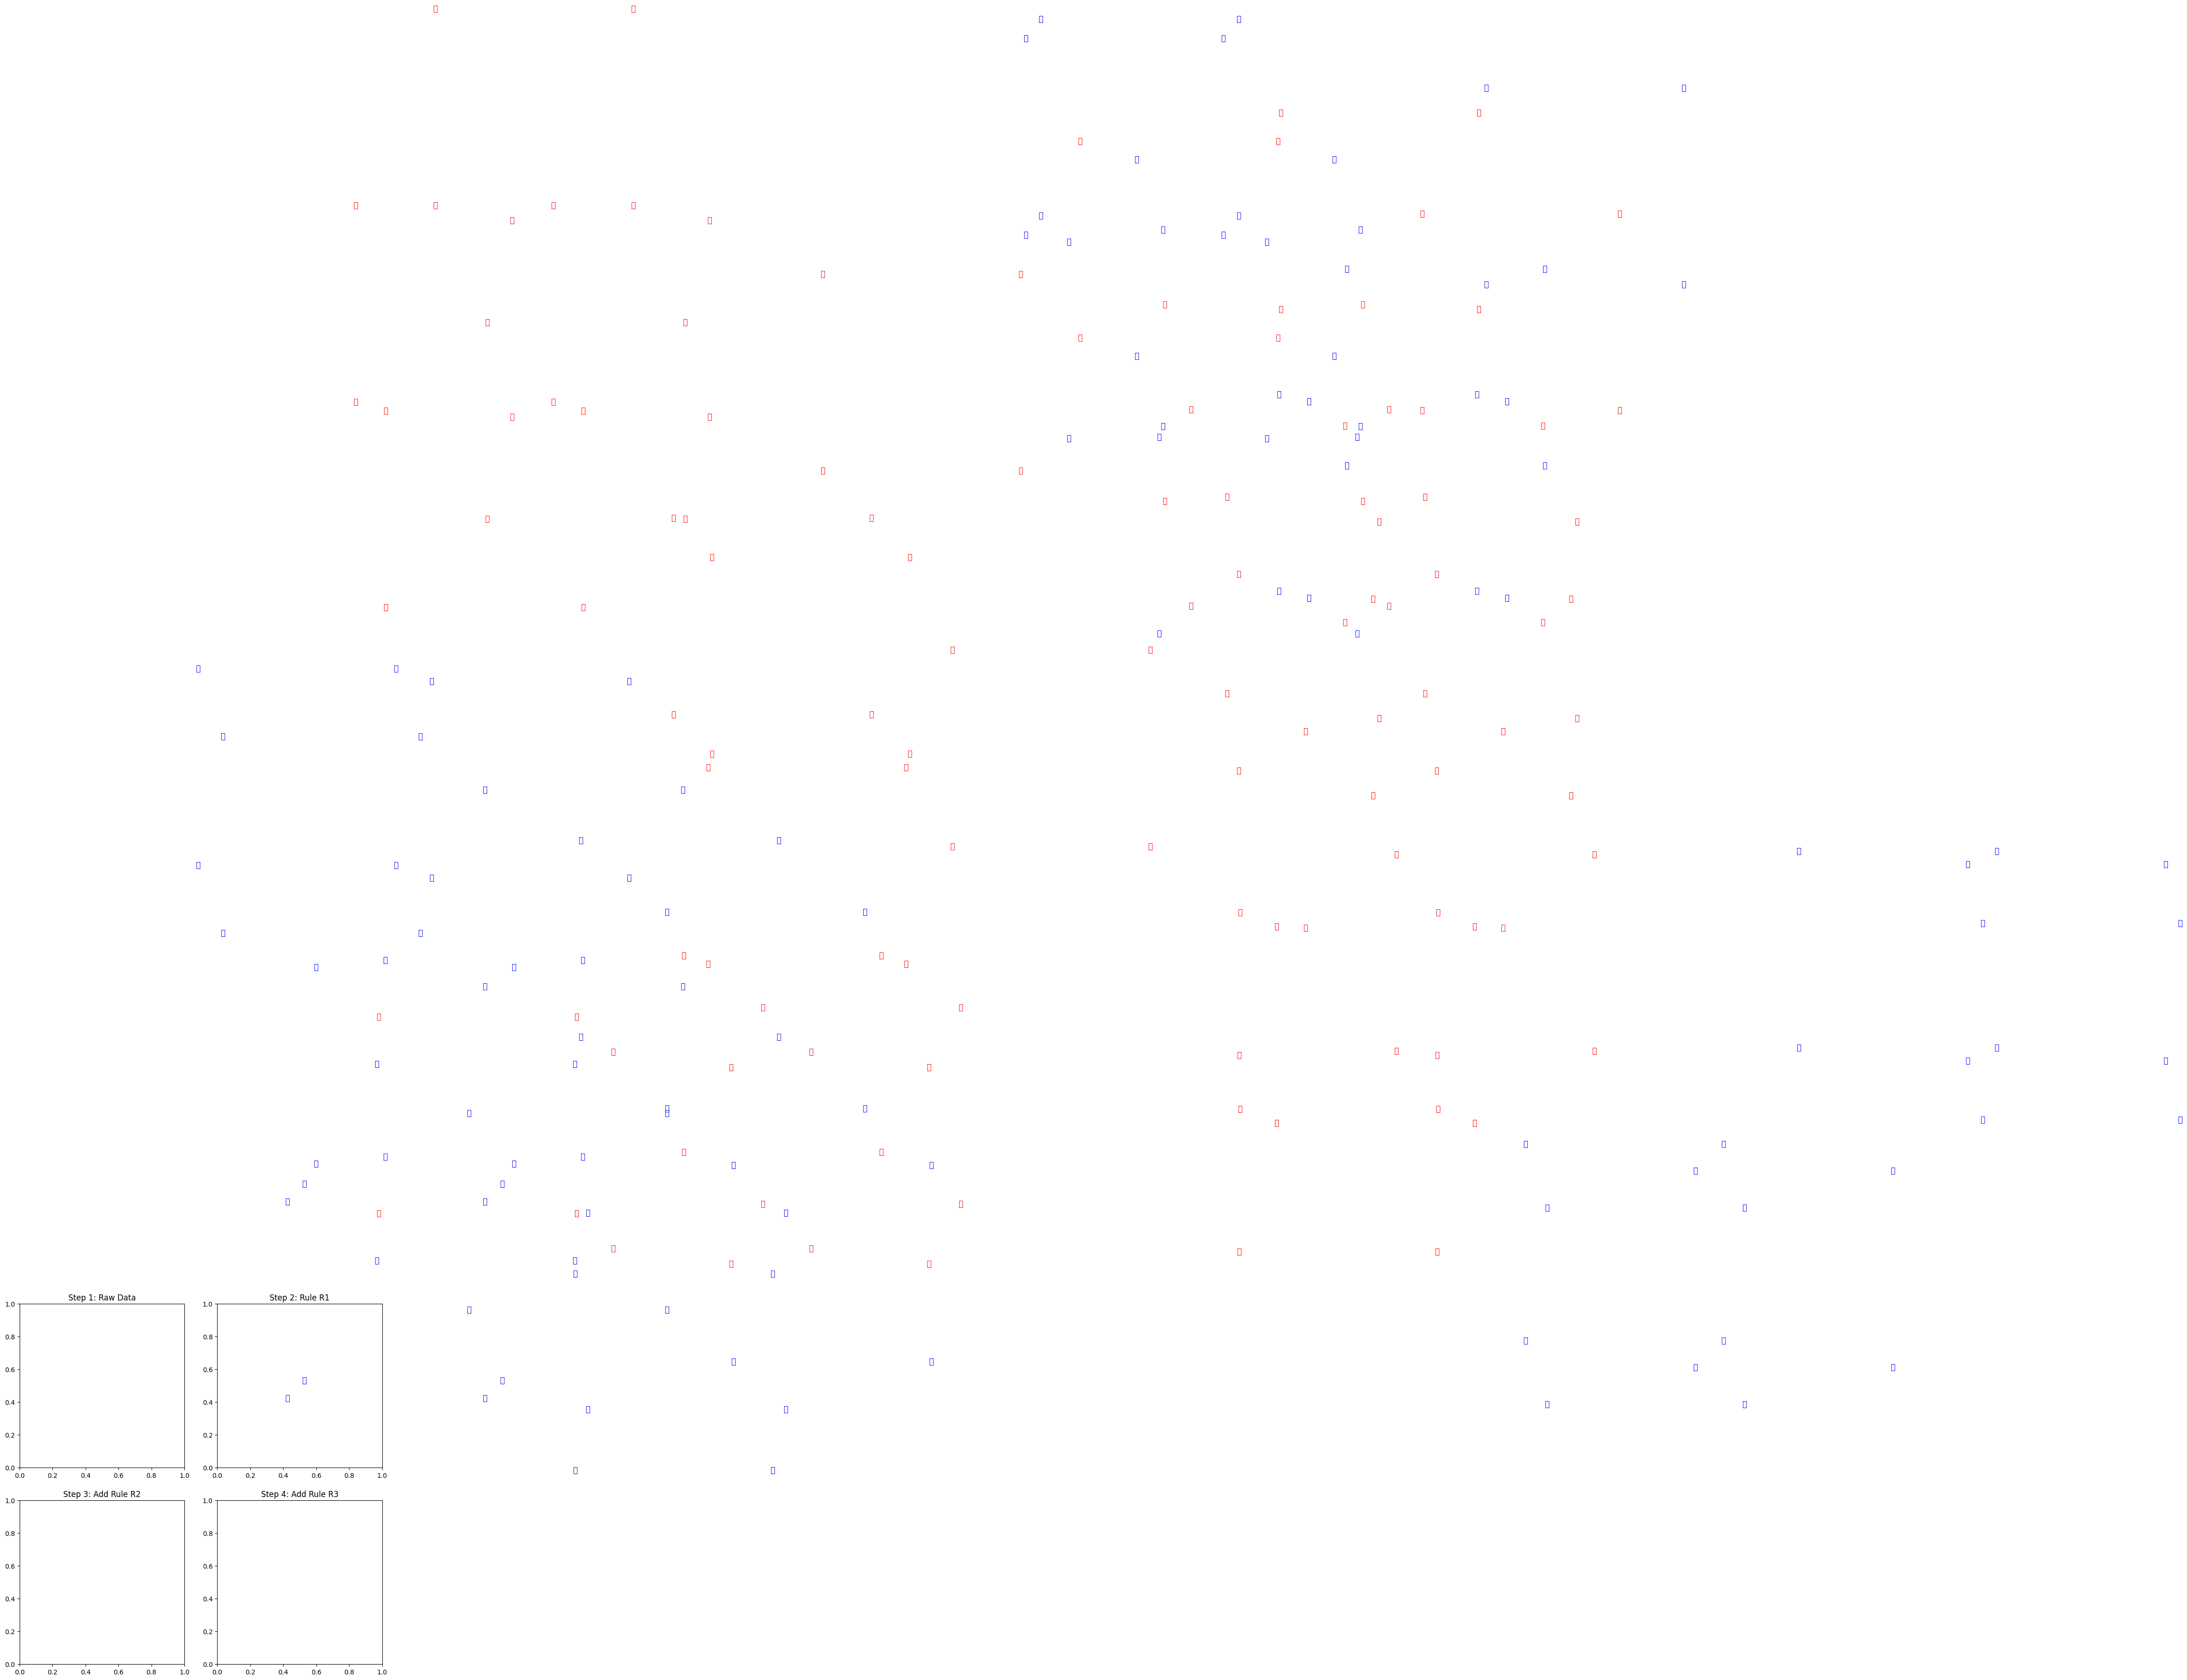

In [ ]:
# Minh họa Sequential Covering với biểu tượng con dê 🐐 và con cừu 🐑
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

# Tạo dữ liệu giả cho Sheep và Goat
sheep_x = np.random.uniform(1, 5, (15, 2))    # Sheep cluster 1
sheep_y = np.random.uniform(6, 9, (10, 2))    # Sheep cluster 2
sheep_z = np.random.uniform(6, 9, (6, 2)) + np.array([[3, -5]])  # Sheep cluster 3
goat = np.random.uniform(2, 9, (30, 2))

sheep = np.vstack([sheep_x, sheep_y, sheep_z])

# Hàm vẽ emoji thay cho marker
def plot_animals(ax, data, symbol, color):
    for (x, y) in data:
        ax.text(x, y, symbol, fontsize=12, ha='center', va='center', color=color)

# Vẽ 4 bước Sequential Covering
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Step 1
plot_animals(axes[0,0], goat, "🐐", "red")
plot_animals(axes[0,0], sheep, "🐑", "blue")
axes[0,0].set_title("Step 1: Raw Data")

# Step 2
plot_animals(axes[0,1], goat, "🐐", "red")
plot_animals(axes[0,1], sheep, "🐑", "blue")
axes[0,1].add_patch(plt.Rectangle((1,1), 4,4, fill=True, alpha=0.2, color="cyan"))
axes[0,1].set_title("Step 2: Rule R1")

# Step 3
plot_animals(axes[1,0], goat, "🐐", "red")
plot_animals(axes[1,0], sheep, "🐑", "blue")
axes[1,0].add_patch(plt.Rectangle((1,1), 4,4, fill=True, alpha=0.2, color="cyan"))
axes[1,0].add_patch(plt.Rectangle((6,6), 3,3, fill=True, alpha=0.2, color="green"))
axes[1,0].set_title("Step 3: Add Rule R2")

# Step 4
plot_animals(axes[1,1], goat, "🐐", "red")
plot_animals(axes[1,1], sheep, "🐑", "blue")
axes[1,1].add_patch(plt.Rectangle((1,1), 4,4, fill=True, alpha=0.2, color="cyan"))
axes[1,1].add_patch(plt.Rectangle((6,6), 3,3, fill=True, alpha=0.2, color="green"))
axes[1,1].add_patch(plt.Rectangle((6,1), 3,3, fill=True, alpha=0.2, color="orange"))
axes[1,1].set_title("Step 4: Add Rule R3")

plt.tight_layout()
plt.show()


C:\Users\PHT\AppData\Local\Temp\ipykernel_2528\129350953.py:55: UserWarning: Glyph 128016 (\N{GOAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PHT\AppData\Local\Temp\ipykernel_2528\129350953.py:55: UserWarning: Glyph 128017 (\N{SHEEP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PHT\AppData\Local\Temp\ipykernel_2528\129350953.py:55: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


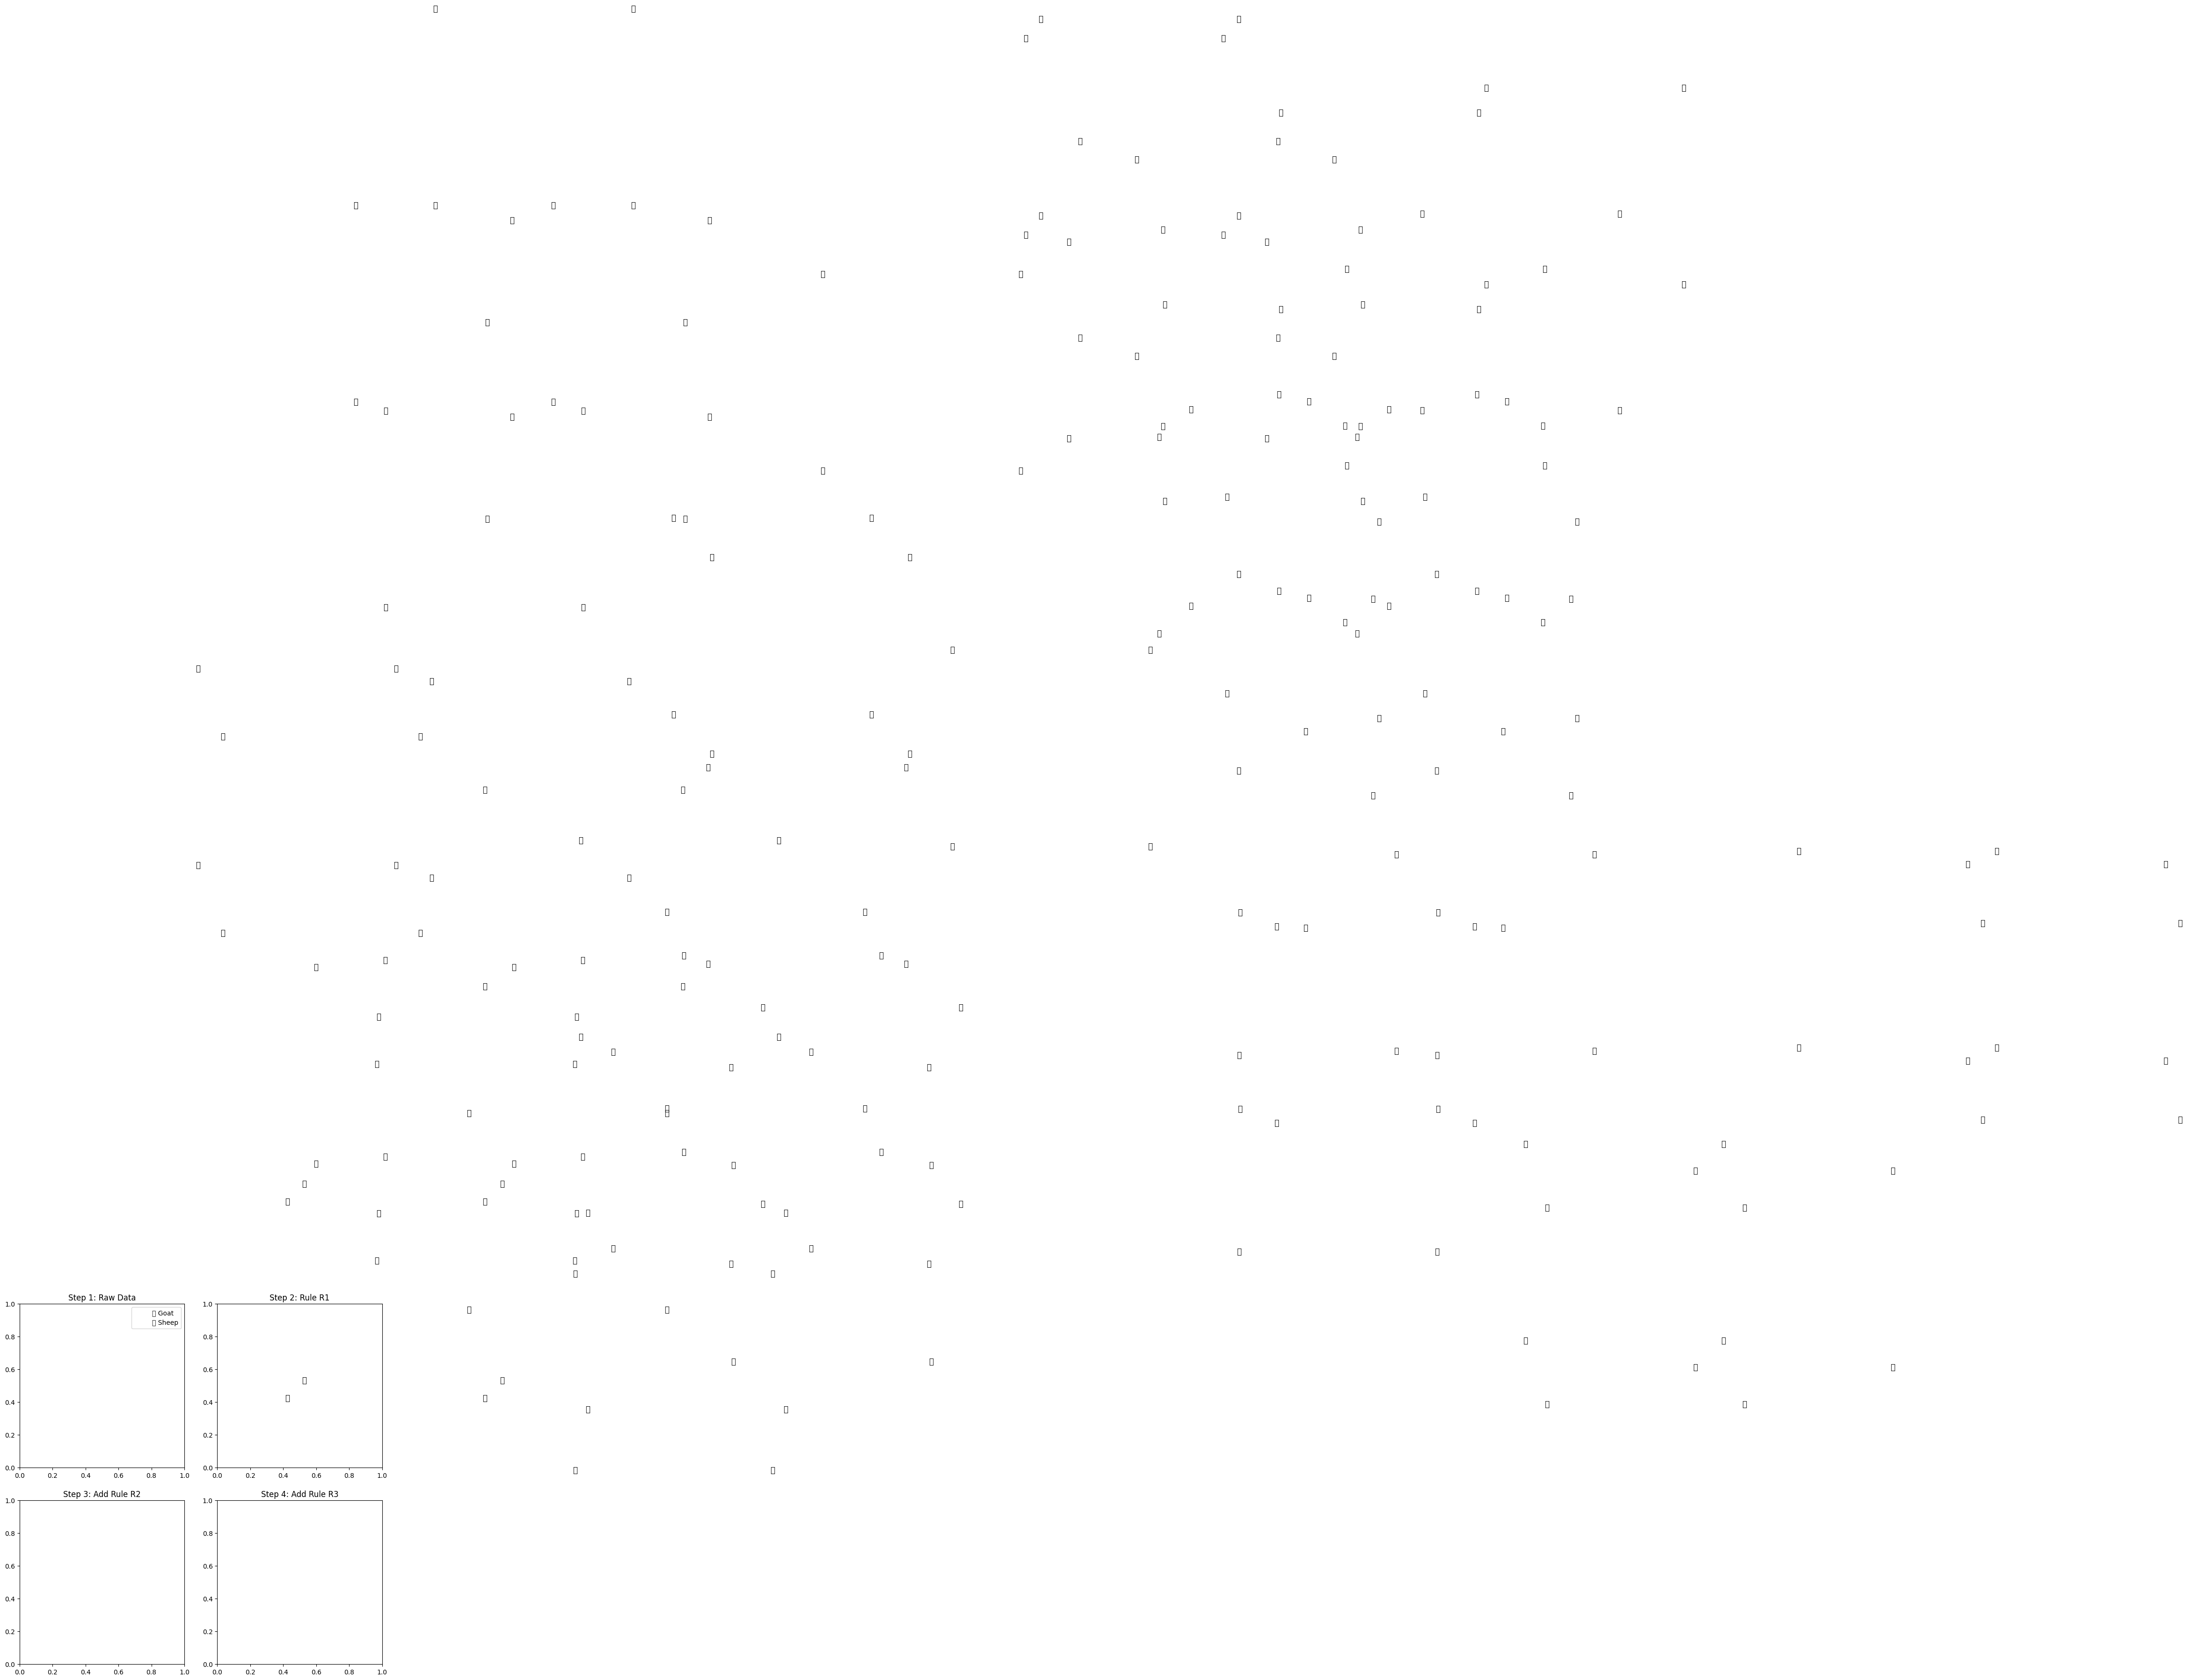

In [ ]:
# Minh họa Sequential Covering với biểu tượng con dê 🐐 và con cừu 🐑
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

np.random.seed(42)

# Tạo dữ liệu giả cho Sheep và Goat
sheep_x = np.random.uniform(1, 5, (15, 2))    # Sheep cluster 1
sheep_y = np.random.uniform(6, 9, (10, 2))    # Sheep cluster 2
sheep_z = np.random.uniform(6, 9, (6, 2)) + np.array([[3, -5]])  # Sheep cluster 3
goat = np.random.uniform(2, 9, (30, 2))

sheep = np.vstack([sheep_x, sheep_y, sheep_z])

# Hàm vẽ emoji thay cho marker
def plot_animals(ax, data, symbol):
    for (x, y) in data:
        ax.text(x, y, symbol, fontsize=12, ha='center', va='center')

# Legend (chú thích)
goat_patch = mpatches.Patch(color='none', label="🐐 Goat")
sheep_patch = mpatches.Patch(color='none', label="🐑 Sheep")

# Vẽ 4 bước Sequential Covering
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Step 1
plot_animals(axes[0,0], goat, "🐐")
plot_animals(axes[0,0], sheep, "🐑")
axes[0,0].set_title("Step 1: Raw Data")
axes[0,0].legend(handles=[goat_patch, sheep_patch], loc="upper right")

# Step 2
plot_animals(axes[0,1], goat, "🐐")
plot_animals(axes[0,1], sheep, "🐑")
axes[0,1].add_patch(plt.Rectangle((1,1), 4,4, fill=True, alpha=0.2, color="cyan"))
axes[0,1].set_title("Step 2: Rule R1")

# Step 3
plot_animals(axes[1,0], goat, "🐐")
plot_animals(axes[1,0], sheep, "🐑")
axes[1,0].add_patch(plt.Rectangle((1,1), 4,4, fill=True, alpha=0.2, color="cyan"))
axes[1,0].add_patch(plt.Rectangle((6,6), 3,3, fill=True, alpha=0.2, color="green"))
axes[1,0].set_title("Step 3: Add Rule R2")

# Step 4
plot_animals(axes[1,1], goat, "🐐")
plot_animals(axes[1,1], sheep, "🐑")
axes[1,1].add_patch(plt.Rectangle((1,1), 4,4, fill=True, alpha=0.2, color="cyan"))
axes[1,1].add_patch(plt.Rectangle((6,6), 3,3, fill=True, alpha=0.2, color="green"))
axes[1,1].add_patch(plt.Rectangle((6,1), 3,3, fill=True, alpha=0.2, color="orange"))
axes[1,1].set_title("Step 4: Add Rule R3")

plt.tight_layout()
plt.show()


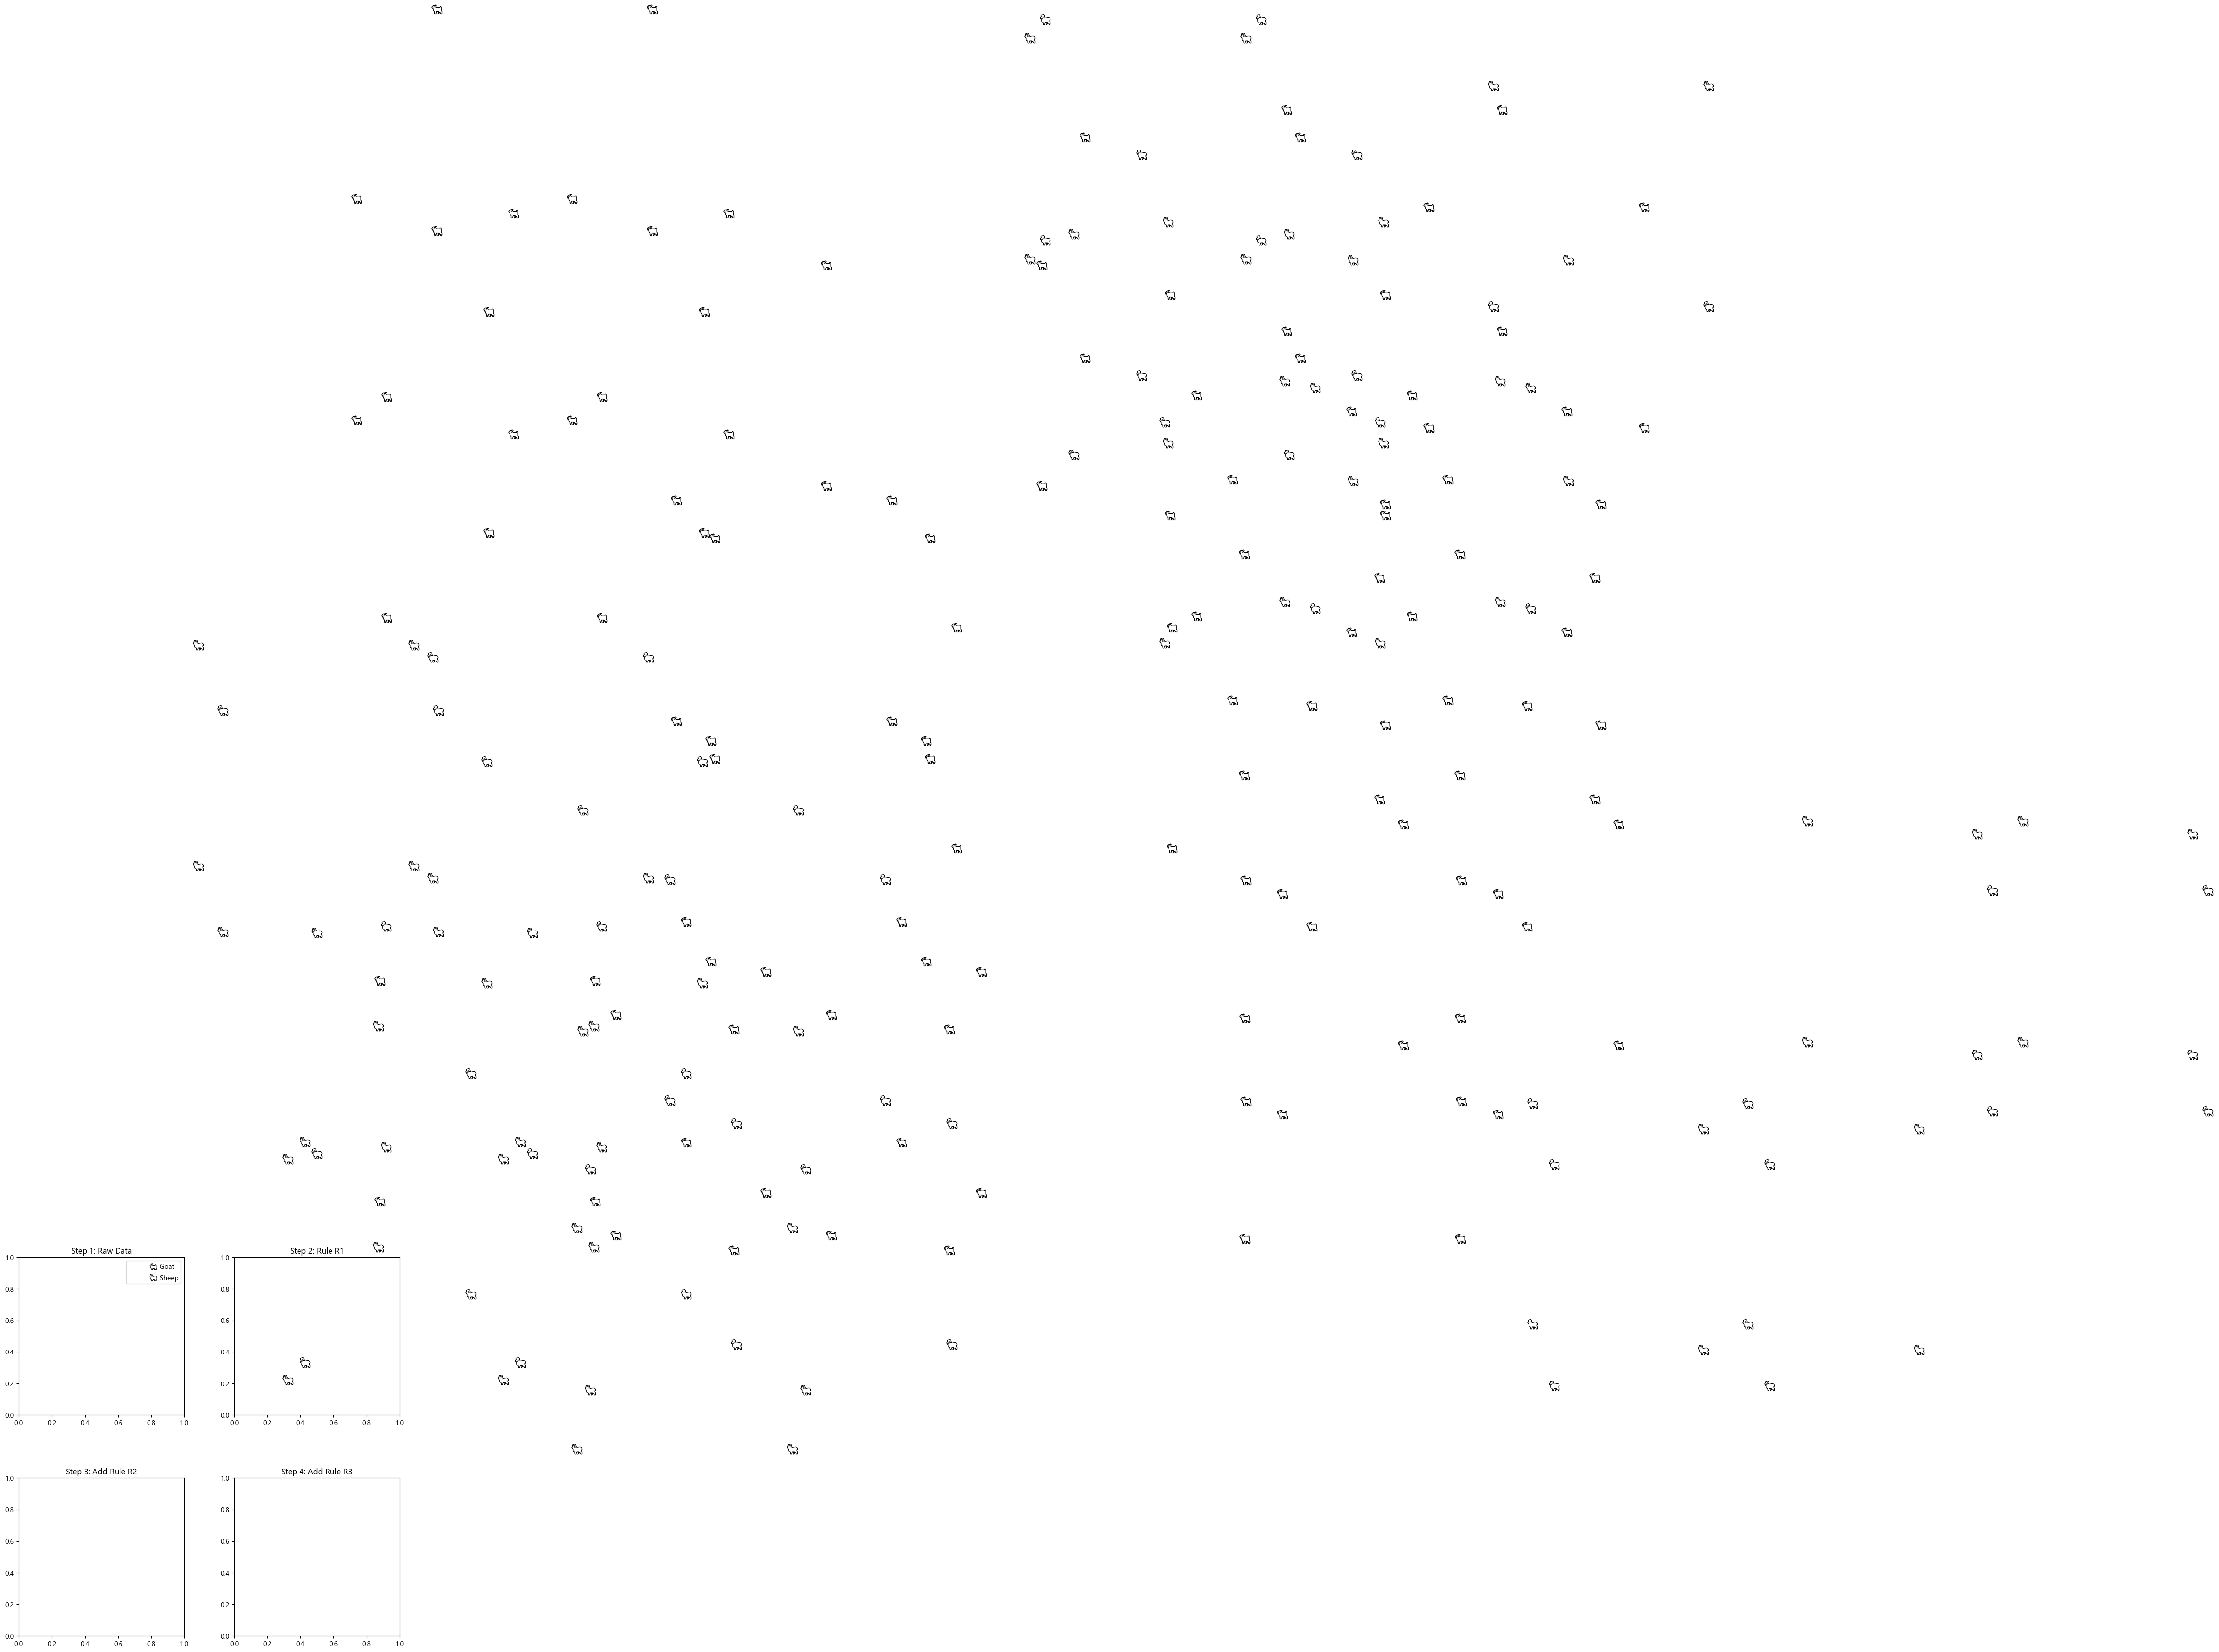

In [ ]:
# Minh họa Sequential Covering với emoji 🐐 và 🐑
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# 🔹 Đặt font hỗ trợ emoji (trên Windows dùng Segoe UI Emoji)
plt.rcParams['font.family'] = 'Segoe UI Emoji'

np.random.seed(42)

# Tạo dữ liệu giả cho Sheep và Goat
sheep_x = np.random.uniform(1, 5, (15, 2))    # Sheep cluster 1
sheep_y = np.random.uniform(6, 9, (10, 2))    # Sheep cluster 2
sheep_z = np.random.uniform(6, 9, (6, 2)) + np.array([[3, -5]])  # Sheep cluster 3
goat = np.random.uniform(2, 9, (30, 2))

sheep = np.vstack([sheep_x, sheep_y, sheep_z])

# Hàm vẽ emoji thay cho marker
def plot_animals(ax, data, symbol):
    for (x, y) in data:
        ax.text(x, y, symbol, fontsize=14, ha='center', va='center')

# Legend (chú thích)
goat_patch = mpatches.Patch(color='none', label="🐐 Goat")
sheep_patch = mpatches.Patch(color='none', label="🐑 Sheep")

# Vẽ 4 bước Sequential Covering
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Step 1
plot_animals(axes[0,0], goat, "🐐")
plot_animals(axes[0,0], sheep, "🐑")
axes[0,0].set_title("Step 1: Raw Data")
axes[0,0].legend(handles=[goat_patch, sheep_patch], loc="upper right")

# Step 2
plot_animals(axes[0,1], goat, "🐐")
plot_animals(axes[0,1], sheep, "🐑")
axes[0,1].add_patch(plt.Rectangle((1,1), 4,4, fill=True, alpha=0.2, color="cyan"))
axes[0,1].set_title("Step 2: Rule R1")

# Step 3
plot_animals(axes[1,0], goat, "🐐")
plot_animals(axes[1,0], sheep, "🐑")
axes[1,0].add_patch(plt.Rectangle((1,1), 4,4, fill=True, alpha=0.2, color="cyan"))
axes[1,0].add_patch(plt.Rectangle((6,6), 3,3, fill=True, alpha=0.2, color="green"))
axes[1,0].set_title("Step 3: Add Rule R2")

# Step 4
plot_animals(axes[1,1], goat, "🐐")
plot_animals(axes[1,1], sheep, "🐑")
axes[1,1].add_patch(plt.Rectangle((1,1), 4,4, fill=True, alpha=0.2, color="cyan"))
axes[1,1].add_patch(plt.Rectangle((6,6), 3,3, fill=True, alpha=0.2, color="green"))
axes[1,1].add_patch(plt.Rectangle((6,1), 3,3, fill=True, alpha=0.2, color="orange"))
axes[1,1].set_title("Step 4: Add Rule R3")

# 🔹 Điều chỉnh khoảng cách giữa các subplot
plt.subplots_adjust(wspace=0.3, hspace=0.4)

plt.show()


## Section 2: Visualization of Rules

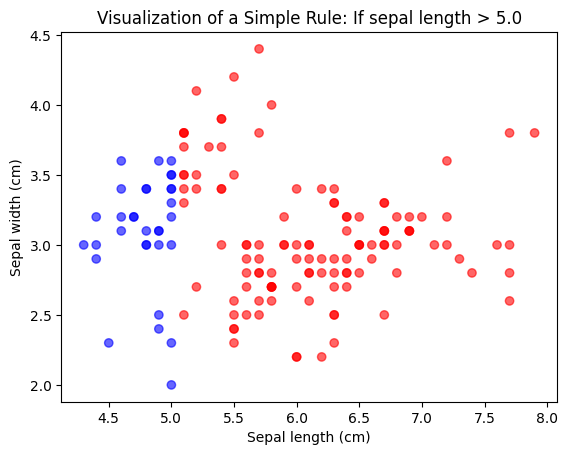

In [ ]:
# Minh họa trực quan một luật đơn giản bằng scatter plot
# Chúng ta sẽ tô màu các điểm theo luật được chọn

import matplotlib.pyplot as plt

rule_condition = df['sepal length (cm)'] > 5.0
colors = ["red" if cond else "blue" for cond in rule_condition]

plt.scatter(df['sepal length (cm)'], df['sepal width (cm)'], c=colors, alpha=0.6)
plt.xlabel("Sepal length (cm)")
plt.ylabel("Sepal width (cm)")
plt.title("Visualization of a Simple Rule: If sepal length > 5.0")
plt.show()

## Section 3: Rule Growing (using DecisionTree as proxy)
We simulate rule growing using a one-level decision tree.

In [ ]:
# Dùng DecisionTreeClassifier với độ sâu = 1 để giả lập việc phát triển một luật
from sklearn.tree import DecisionTreeClassifier

X, y = df[['sepal length (cm)', 'sepal width (cm)']], df['target']
clf = DecisionTreeClassifier(max_depth=1)
clf.fit(X, y)

print("Extracted condition (feature index, threshold):",
      clf.tree_.feature[0], clf.tree_.threshold[0])

Extracted condition (feature index, threshold): 0 5.450000047683716


## Section 4: Information Gain Calculation

In [ ]:
# Tính toán entropy và information gain thủ công cho một thuộc tính đơn giản
import numpy as np
from collections import Counter
import math

def entropy(y):
    counts = Counter(y)
    total = len(y)
    return -sum((count/total) * math.log2(count/total) for count in counts.values())

def information_gain(y, x):
    # Entropy trước khi chia
    base_entropy = entropy(y)
    values = set(x)
    weighted_entropy = 0
    for v in values:
        y_sub = [y[i] for i in range(len(y)) if x[i] == v]
        weighted_entropy += (len(y_sub)/len(y)) * entropy(y_sub)
    return base_entropy - weighted_entropy

y_vals = df['target'].tolist()
x_vals = (df['sepal length (cm)'] > 5.0).astype(int).tolist()

print("Information Gain for rule (sepal length > 5.0):",
      information_gain(y_vals, x_vals))

Information Gain for rule (sepal length > 5.0): 0.2616484973584483


## Section 5: Pruning Example

In [ ]:
# Minh họa cắt tỉa: bỏ điều kiện không cải thiện
rule_conditions = ["sepal length > 5.0", "sepal width > 3.0"]
print("Original rule:", " AND ".join(rule_conditions))

# Giả sử điều kiện thứ 2 không cải thiện => bỏ đi
pruned_rule = [rule_conditions[0]]
print("Pruned rule:", " AND ".join(pruned_rule))

Original rule: sepal length > 5.0 AND sepal width > 3.0
Pruned rule: sepal length > 5.0


## Section 6: Optimization Step (Conceptual)
We demonstrate reordering/revising rules conceptually.

In [ ]:
# Minh họa khái niệm tối ưu: sắp xếp lại luật để giảm lỗi
rules = [
    ("If sepal length > 6.0 THEN class = virginica", 0.9),
    ("If sepal width < 3.0 THEN class = versicolor", 0.95)
]

# Giả sử ta muốn ưu tiên luật có độ chính xác cao hơn
rules_sorted = sorted(rules, key=lambda x: x[1], reverse=True)

print("Rules before optimization:")
for r in rules:
    print(r)
print("\nRules after optimization:")
for r in rules_sorted:
    print(r)

Rules before optimization:
('If sepal length > 6.0 THEN class = virginica', 0.9)
('If sepal width < 3.0 THEN class = versicolor', 0.95)

Rules after optimization:
('If sepal width < 3.0 THEN class = versicolor', 0.95)
('If sepal length > 6.0 THEN class = virginica', 0.9)
